# Удовлетворение и увольнение

HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.

Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. 

Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли. 

У вас будет несколько задач. Первая — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. 

Почему бизнесу это важно: удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.

Ваша вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

Теперь расскажем подробнее о задачах.

## Задача 1: предсказание уровня удовлетворённости сотрудника

Для этой задачи заказчик предоставил данные с признаками:

id — уникальный идентификатор сотрудника;

dept — отдел, в котором работает сотрудник;

level — уровень занимаемой должности;

workload — уровень загруженности сотрудника;

employment_years — длительность работы в компании (в годах);

last_year_promo — показывает, было ли повышение за последний год;

last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;

supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;

salary — ежемесячная зарплата сотрудника;

job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак.

In [1]:
!pip install -q phik
!pip install --upgrade scikit-learn

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix  # для себя, чтобы визуализировать
from phik.report import plot_correlation_matrix

from sklearn.compose import ColumnTransformer  # для общего пайплайна в подготовке данных
from sklearn.impute import SimpleImputer  # для задания в шаге 2
from sklearn.linear_model import LinearRegression, LogisticRegression  # для итогового пайплайна
from sklearn.metrics import (
    make_scorer,
    roc_auc_score,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    GridSearchCV,
    KFold  # для smare. Без него у меня выходит nan в Метрике лучшей модели на трен.выборке
)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier  # минимум две модели
from sklearn.pipeline import Pipeline  # для пайплайнов
from sklearn.preprocessing import (
    OneHotEncoder,
    LabelEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

np.set_printoptions(threshold=np.inf)  # для smare

### Шаг 1. Загрузка данных



In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

#### Загрузите файлы с данными:

Тренировочная выборка:

train_job_satisfaction_rate.csv



In [4]:
train_job_satisfaction_rate = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
display(train_job_satisfaction_rate.head())
train_job_satisfaction_rate.info()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


Входные признаки тестовой выборки:

test_features.csv

In [5]:
test_features = pd.read_csv('/datasets/test_features.csv')
display(test_features.head())
test_features.info()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


Целевой признак тестовой выборки:

test_target_job_satisfaction_rate.csv

In [6]:
test_target_job_satisfaction_rate = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')
display(test_target_job_satisfaction_rate.head())
test_target_job_satisfaction_rate.info() 

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


#### Промежуточный вывод по шагу 1.

Интересно, что мне заранее предоставили разделенный на тренеровочную и тестовую выборки датасет. Да еще и целевой признак в оттдельный датафрейм вынесен.

Разделение данных нормальное. Загрузились без проблем.
В тренировочной и тестовой выборке обнаружены пропуски. А именно в столбцах 'dept' и 'level'
Типы данных в колонках менять не надо.
Названия колонок менять не нужно.

Данные соответствуют описанию. 

### Шаг 2. Предобработка данных



#### Изучение данных



In [7]:
print('уникальные значения в колонках тренировочной выборки')
print('В dept:', (train_job_satisfaction_rate['dept'].unique()))
print('В level:', (train_job_satisfaction_rate['level'].unique()))
print('В workload:', (train_job_satisfaction_rate['workload'].unique()))
print('В employment_years:', (train_job_satisfaction_rate['employment_years'].unique()))
print('В last_year_promo:', (train_job_satisfaction_rate['last_year_promo'].unique()))
print('В last_year_violations:', (train_job_satisfaction_rate['last_year_violations'].unique()))
print('В supervisor_evaluation:', (train_job_satisfaction_rate['supervisor_evaluation'].unique()))


уникальные значения в колонках тренировочной выборки
В dept: ['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
В level: ['junior' 'middle' 'sinior' nan]
В workload: ['medium' 'high' 'low']
В employment_years: [ 2  1  4  7  9  6  3 10  8  5]
В last_year_promo: ['no' 'yes']
В last_year_violations: ['no' 'yes']
В supervisor_evaluation: [1 5 2 3 4]


senior пишется не так.

In [8]:
print('уникальные значения в колонках тестовой выборки')
print('В dept:', (test_features['dept'].unique()))
print('В level:', (test_features['level'].unique()))
print('В workload:', (test_features['workload'].unique()))
print('В employment_years:', (test_features['employment_years'].unique()))
print('В last_year_promo:', (test_features['last_year_promo'].unique()))
print('В last_year_violations:', (test_features['last_year_violations'].unique()))
print('В supervisor_evaluation:', (test_features['supervisor_evaluation'].unique()))


уникальные значения в колонках тестовой выборки
В dept: ['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
В level: ['junior' 'middle' 'sinior' nan]
В workload: ['medium' 'low' 'high' ' ']
В employment_years: [ 2  1  5  6  3  9  7  4  8 10]
В last_year_promo: ['no' 'yes']
В last_year_violations: ['no' 'yes']
В supervisor_evaluation: [5 4 3 1 2]


Помимо nan значений обнаружены еще и пустые пробелы ' '. Я заменю их на nan



#### Предобработка данных.

In [9]:
test_features['dept'] = test_features['dept'].replace(' ', np.nan)
test_features['workload'] = test_features['workload'].replace(' ', np.nan)

И посмотрю на общую картину пропусков.

In [10]:
print('Неявных дубликатов в train_job_satisfaction_rate:\n', train_job_satisfaction_rate.isna().sum())
print('Неявных дубликатов в test_features:\n', test_features.isna().sum())
print('Неявных дубликатов в test_target_job_satisfaction_rate:\n', test_target_job_satisfaction_rate.isna().sum())

Неявных дубликатов в train_job_satisfaction_rate:
 id                       0
dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64
Неявных дубликатов в test_features:
 id                       0
dept                     3
level                    1
workload                 1
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64
Неявных дубликатов в test_target_job_satisfaction_rate:
 id                       0
job_satisfaction_rate    0
dtype: int64


In [11]:
train_job_satisfaction_rate[train_job_satisfaction_rate['dept'].isnull() | train_job_satisfaction_rate['level'].isnull()]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1209,631073,sales,NaN,medium,1,no,no,4,27600,0.66
1469,416327,sales,NaN,low,1,no,no,5,18000,0.73
1526,694746,NaN,junior,medium,5,no,no,4,21600,0.62
1630,814624,NaN,junior,medium,3,no,no,4,24000,0.88
1633,475114,NaN,junior,high,4,no,no,4,31200,0.63
1745,135043,sales,NaN,medium,1,no,no,3,26400,0.30
2522,998838,sales,NaN,medium,1,no,no,5,27600,0.71
2781,497243,NaN,junior,medium,1,no,no,3,26400,0.28
2975,168668,NaN,junior,low,3,no,no,4,18000,0.88
3866,641150,NaN,junior,low,3,no,yes,4,12000,0.54


In [12]:
test_features[test_features['dept'].isnull() | test_features['level'].isnull() | test_features['workload'].isnull()]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
15,590867,marketing,junior,NaN,4,no,no,4,28800
191,609865,NaN,junior,medium,1,no,no,1,20400
312,471990,sales,NaN,low,1,no,no,3,12000
1196,832342,NaN,junior,medium,1,no,no,4,28800
1699,822186,NaN,middle,medium,3,no,no,4,38400


Их немного. Можно заменить на моду. (это object значения, по другому никак)

Я их не удалил, так как они не совпадают по id и в будущем при анализе это могло привести к несостыковке и утере данных.

В общем я думаю, что замена на моду это оптимальный вариант избавления от nan в данном случае.

НО в задании сказано 'Если есть пропуски, заполните их в пайплайне.'
а потому:

##### Заполнение пропусков пайплайном:

~Использую SimpleImputer, библиотеку которой скачал ранее.~

In [13]:
#isnull_pipe = Pipeline(
#    [
#        (
#            'SimpleImputer',
#            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
#        ),
#    ]
#)
#train_job_satisfaction_rate[['dept', 'level']] = isnull_pipe.fit_transform(train_job_satisfaction_rate[['dept', 'level']])
#test_features[['dept', 'level', 'workload']] = isnull_pipe.fit_transform(test_features[['dept', 'level', 'workload']])

~В принципе, это тоже замена на моду.~

#### Проверка на явные дубликаты

In [14]:
print('Явных дубликатов в train_job_satisfaction_rate:', train_job_satisfaction_rate.duplicated().sum())
print('Явных дубликатов в test_features:', test_features.duplicated().sum())
print('Явных дубликатов в test_target_job_satisfaction_rate:', test_target_job_satisfaction_rate.duplicated().sum())

Явных дубликатов в train_job_satisfaction_rate: 0
Явных дубликатов в test_features: 0
Явных дубликатов в test_target_job_satisfaction_rate: 0


#### Проверка на неявные дубликаты

In [15]:
print('Неявных дубликатов в train_job_satisfaction_rate:', train_job_satisfaction_rate.isna().sum().sum())
print('Неявных дубликатов в test_features:', test_features.isna().sum().sum())
print('Неявных дубликатов в test_target_job_satisfaction_rate:', test_target_job_satisfaction_rate.isna().sum().sum())

Неявных дубликатов в train_job_satisfaction_rate: 10
Неявных дубликатов в test_features: 5
Неявных дубликатов в test_target_job_satisfaction_rate: 0


#### Промежуточный вывод по шагу 2.

В колонках тренировочной выборки dept и level избавится от nan заменой на медиану или средним нельзя, так как это object.

В тестовой nan есть еще и в workload. А почему? Это заставляет меня сомневаться в том, что данные разделены на выборки верно.

Я их заменил на моду с помощью пайплайна.

### Шаг 3. Исследовательский анализ данных

Исследуйте все признаки и сделайте выводы о том, как их нужно подготовить.

In [16]:
display(train_job_satisfaction_rate.describe().T)
display(test_features.describe().T)
display(test_target_job_satisfaction_rate.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,4000.0,544957.621000,257883.104622,100954.00,322836.75,534082.50,771446.00,999521.0
employment_years,4000.0,3.718500,2.542513,1.00,2.00,3.00,6.00,10.0
supervisor_evaluation,4000.0,3.476500,1.008812,1.00,3.00,4.00,4.00,5.0
salary,4000.0,33926.700000,14900.703838,12000.00,22800.00,30000.00,43200.00,98400.0
job_satisfaction_rate,4000.0,0.533995,0.225327,0.03,0.36,0.56,0.71,1.0


,count,mean,std,min,25%,50%,75%,max
id,2000.0,552765.2135,253851.326129,100298.0,339052.0,550793.0,765763.75,999029.0
employment_years,2000.0,3.6665,2.537222,1.0,1.0,3.0,6.00,10.0
supervisor_evaluation,2000.0,3.5265,0.996892,1.0,3.0,4.0,4.00,5.0
salary,2000.0,34066.8000,15398.436729,12000.0,22800.0,30000.0,43200.00,96000.0


,count,mean,std,min,25%,50%,75%,max
id,2000.0,552765.21350,253851.326129,100298.00,339052.00,550793.00,765763.75,999029.0
job_satisfaction_rate,2000.0,0.54878,0.220110,0.03,0.38,0.58,0.72,1.0


#### Колличественные признаки тренировочной выборки. В них войдет и целевой признак.

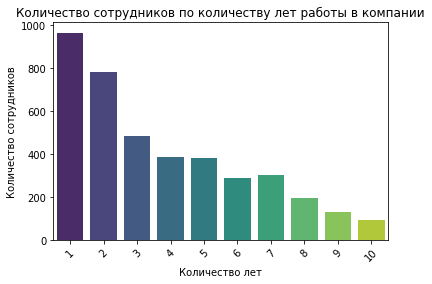

In [17]:

sns.countplot(x='employment_years', data=train_job_satisfaction_rate, palette='viridis')
plt.title('Количество сотрудников по количеству лет работы в компании')
plt.xlabel('Количество лет')
plt.ylabel('Количество сотрудников')
plt.xticks(rotation=45)
plt.show()


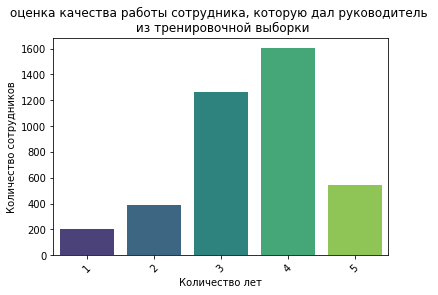

In [18]:

sns.countplot(x='supervisor_evaluation', data=train_job_satisfaction_rate, palette='viridis')
plt.title('оценка качества работы сотрудника, которую дал руководитель \n из тренировочной выборки')
plt.xlabel('Количество лет')
plt.ylabel('Количество сотрудников')
plt.xticks(rotation=45)
plt.show()


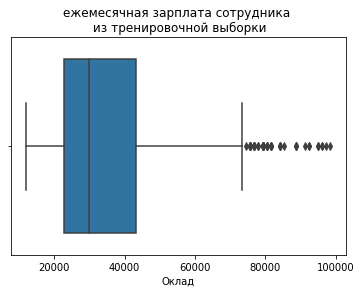

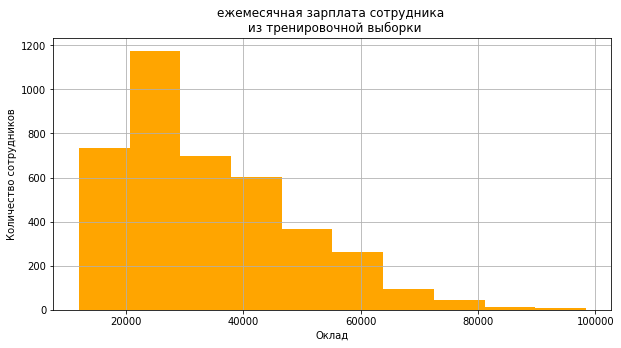

In [19]:
sns.boxplot(x=train_job_satisfaction_rate['salary'])
plt.title('ежемесячная зарплата сотрудника \n из тренировочной выборки')
plt.xlabel('Оклад')
plt.show()
train_job_satisfaction_rate['salary'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=10, color='orange')
plt.xlim()
plt.title('ежемесячная зарплата сотрудника \n из тренировочной выборки')
plt.ylabel('Количество сотрудников')
plt.xlabel('Оклад')
plt.show()

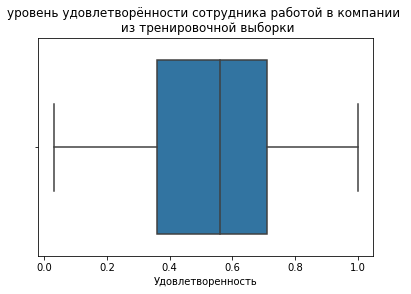

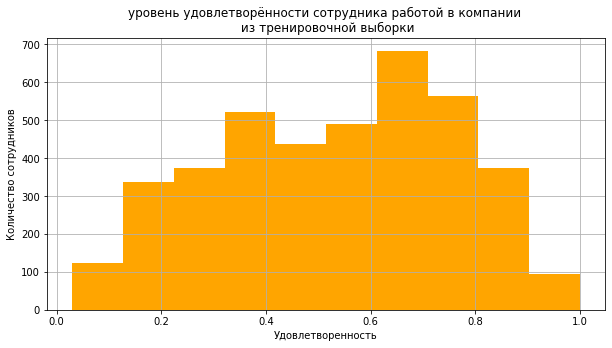

In [20]:
sns.boxplot(x=train_job_satisfaction_rate['job_satisfaction_rate'])
plt.title('уровень удовлетворённости сотрудника работой в компании \n из тренировочной выборки')
plt.xlabel('Удовлетворенность')
plt.show()
train_job_satisfaction_rate['job_satisfaction_rate'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=10, color='orange')
plt.xlim()
plt.title('уровень удовлетворённости сотрудника работой в компании \n из тренировочной выборки')
plt.ylabel('Количество сотрудников')
plt.xlabel('Удовлетворенность')
plt.show()

#### Колличественные признаки тестовой выборки.

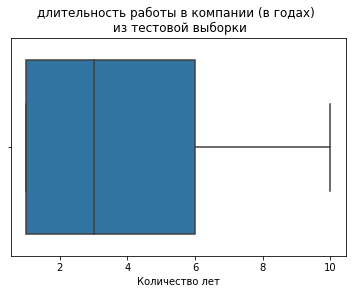

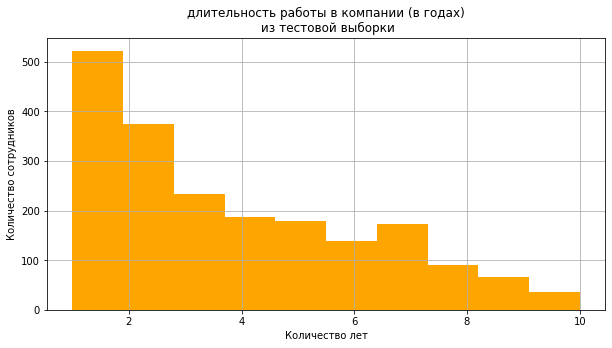

In [21]:
sns.boxplot(x=test_features['employment_years'])
plt.title('длительность работы в компании (в годах) \n из тестовой выборки')
plt.xlabel('Количество лет')
plt.show()
test_features['employment_years'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=10, color='orange')
plt.xlim()
plt.title('длительность работы в компании (в годах)\n из тестовой выборки')
plt.ylabel('Количество сотрудников')
plt.xlabel('Количество лет')
plt.show()

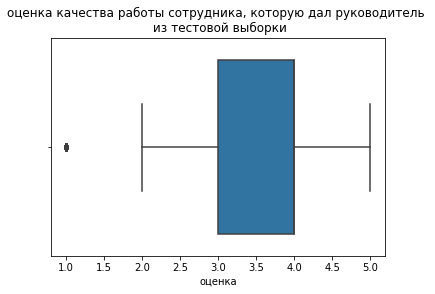

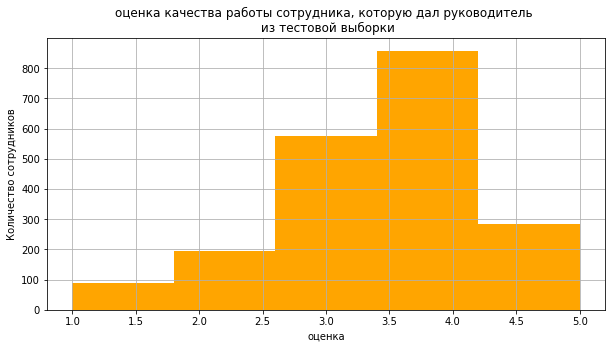

In [22]:
sns.boxplot(x=test_features['supervisor_evaluation'])
plt.title('оценка качества работы сотрудника, которую дал руководитель \n из тестовой выборки')
plt.xlabel('оценка')
plt.show()

test_features['supervisor_evaluation'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=5, color='orange')
plt.xlim()
plt.title('оценка качества работы сотрудника, которую дал руководитель \n из тестовой выборки')
plt.ylabel('Количество сотрудников')
plt.xlabel('оценка')
plt.show()

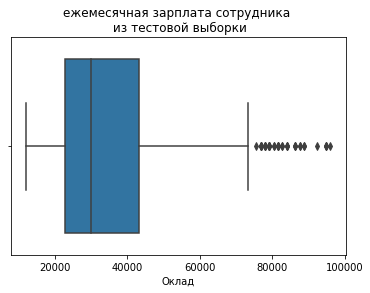

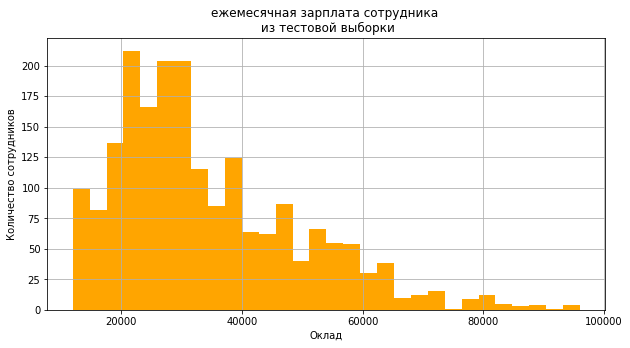

In [23]:
sns.boxplot(x=test_features['salary'])
plt.title('ежемесячная зарплата сотрудника \n из тестовой выборки')
plt.xlabel('Оклад')
plt.show()
test_features['salary'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=30, color='orange')
plt.xlim()
plt.title('ежемесячная зарплата сотрудника \n из тестовой выборки')
plt.ylabel('Количество сотрудников')
plt.xlabel('Оклад')
plt.show()

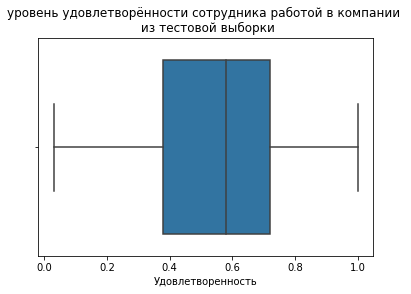

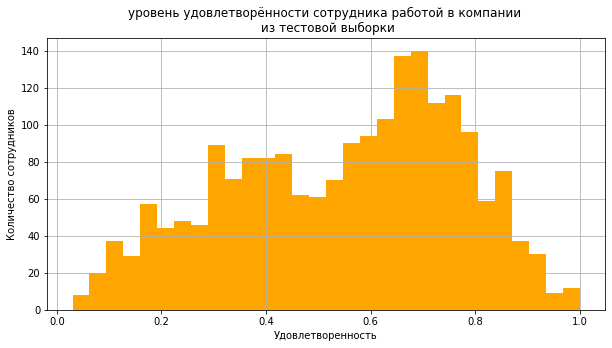

In [24]:
sns.boxplot(x=test_target_job_satisfaction_rate['job_satisfaction_rate'])
plt.title('уровень удовлетворённости сотрудника работой в компании \n из тестовой выборки')
plt.xlabel('Удовлетворенность')
plt.show()
test_target_job_satisfaction_rate['job_satisfaction_rate'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=30, color='orange')
plt.xlim()
plt.title('уровень удовлетворённости сотрудника работой в компании \n из тестовой выборки')
plt.ylabel('Количество сотрудников')
plt.xlabel('Удовлетворенность')
plt.show()

#### Качественные признаки тренировочной выборки

In [25]:
train_job_satisfaction_rate.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


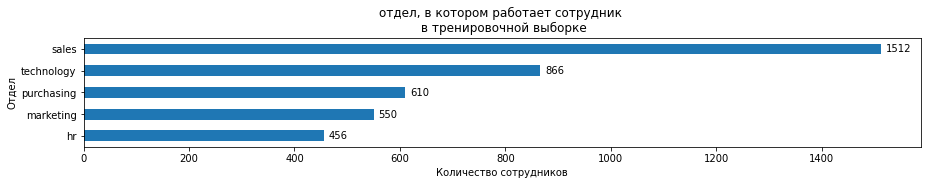

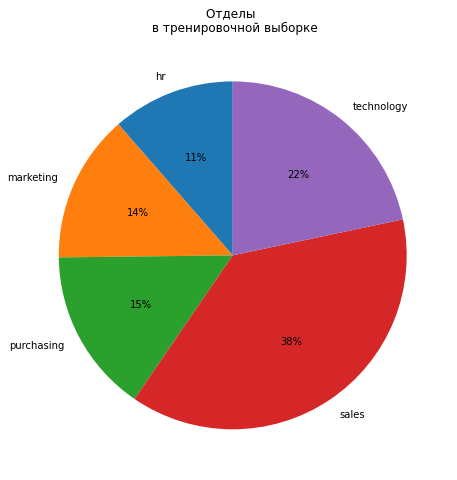

In [26]:
ax = train_job_satisfaction_rate['dept'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='отдел, в котором работает сотрудник \n в тренировочной выборке'
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    
plt.xlabel('Количество cотрудников')
plt.ylabel('Отдел')
plt.show()

ax = train_job_satisfaction_rate.pivot_table(index='dept', values='id', aggfunc='count').reset_index()
plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['dept'], startangle=90, autopct = "%.0f%%")
plt.title('Отделы \n в тренировочной выборке')
plt.show()




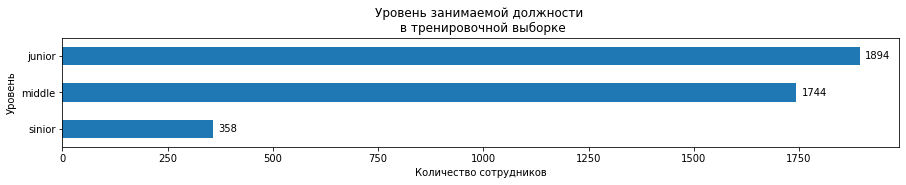

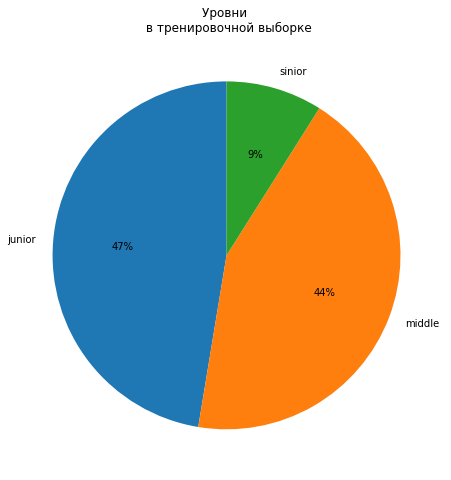

In [27]:
ax = train_job_satisfaction_rate['level'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='Уровень занимаемой должности \n в тренировочной выборке'
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    
plt.xlabel('Количество cотрудников')
plt.ylabel('Уровень')
plt.show()

ax = train_job_satisfaction_rate.pivot_table(index='level', values='id', aggfunc='count').reset_index()
plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['level'], startangle=90, autopct = "%.0f%%")
plt.title('Уровни \n в тренировочной выборке')
plt.show()



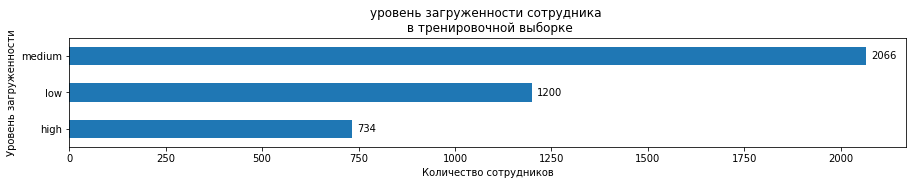

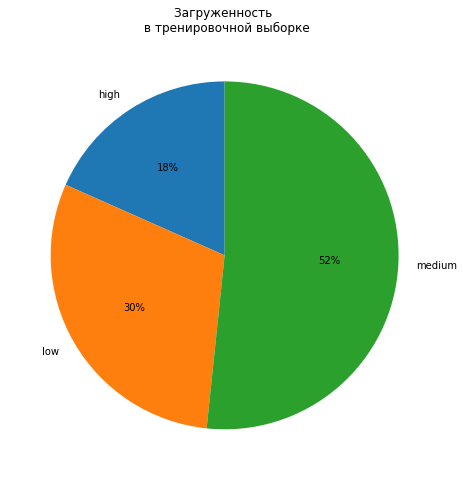

In [28]:
ax = train_job_satisfaction_rate['workload'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='уровень загруженности сотрудника \n в тренировочной выборке'
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    
plt.xlabel('Количество cотрудников')
plt.ylabel('Уровень загруженности')
plt.show()

ax = train_job_satisfaction_rate.pivot_table(index='workload', values='id', aggfunc='count').reset_index()
plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['workload'], startangle=90, autopct = "%.0f%%")
plt.title('Загруженность \n в тренировочной выборке')
plt.show()




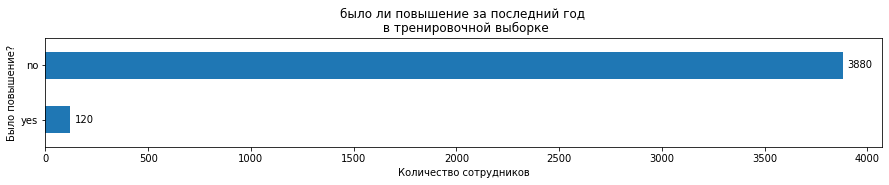

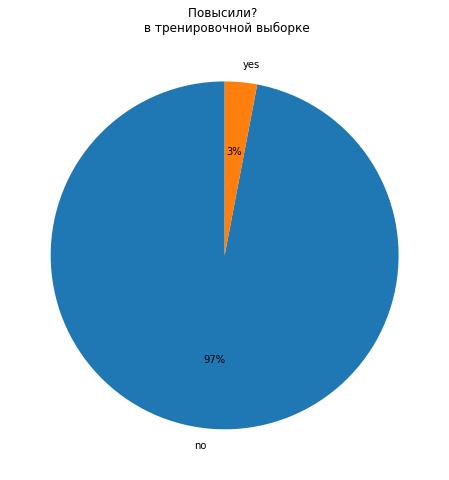

In [29]:
ax = train_job_satisfaction_rate['last_year_promo'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='было ли повышение за последний год \n в тренировочной выборке'
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    
plt.xlabel('Количество cотрудников')
plt.ylabel('Было повышение?')
plt.show()

ax = train_job_satisfaction_rate.pivot_table(index='last_year_promo', values='id', aggfunc='count').reset_index()
plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['last_year_promo'], startangle=90, autopct = "%.0f%%")
plt.title('Повысили? \n в тренировочной выборке')
plt.show()




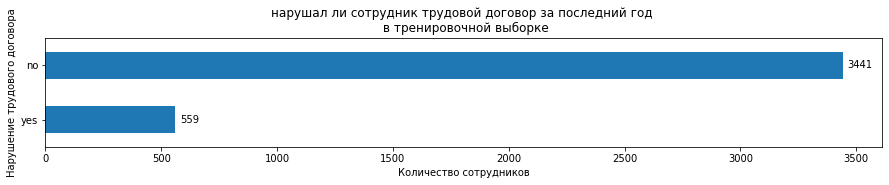

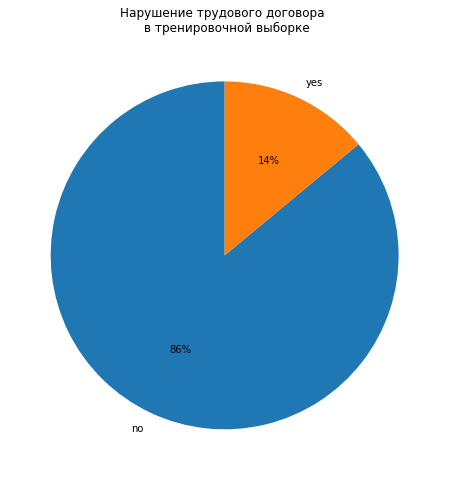

In [30]:
ax = train_job_satisfaction_rate['last_year_violations'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='нарушал ли сотрудник трудовой договор за последний год \n в тренировочной выборке'
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    
plt.xlabel('Количество cотрудников')
plt.ylabel('Нарушение трудового договора')
plt.show()

ax = train_job_satisfaction_rate.pivot_table(index='last_year_violations', values='id', aggfunc='count').reset_index()
plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['last_year_violations'], startangle=90, autopct = "%.0f%%")
plt.title('Нарушение трудового договора \n в тренировочной выборке')
plt.show()

#### Качественные признаки тестовой выборки

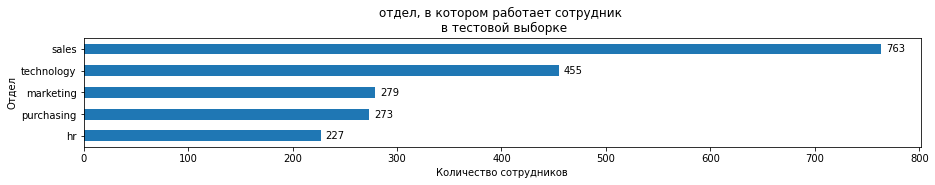

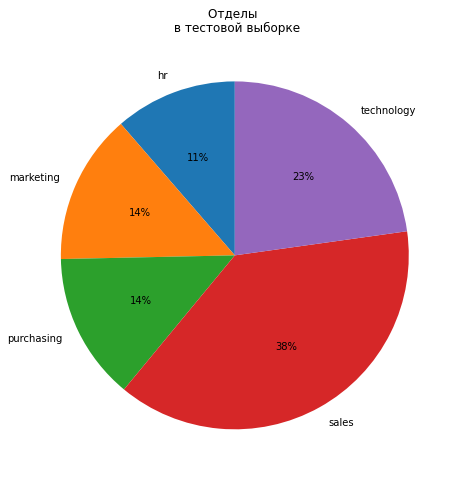

In [31]:
ax = test_features['dept'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='отдел, в котором работает сотрудник \n в тестовой выборке'
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    
plt.xlabel('Количество cотрудников')
plt.ylabel('Отдел')
plt.show()

ax = test_features.pivot_table(index='dept', values='id', aggfunc='count').reset_index()
plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['dept'], startangle=90, autopct = "%.0f%%")
plt.title('Отделы \n в тестовой выборке')
plt.show()

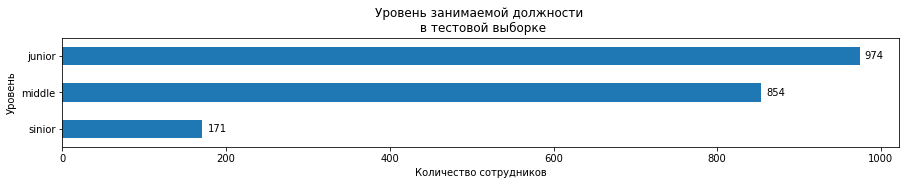

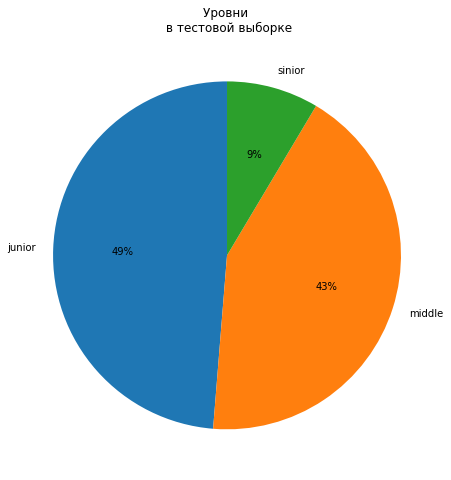

In [32]:
ax = test_features['level'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='Уровень занимаемой должности \n в тестовой выборке'
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    
plt.xlabel('Количество cотрудников')
plt.ylabel('Уровень')
plt.show()

ax = test_features.pivot_table(index='level', values='id', aggfunc='count').reset_index()
plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['level'], startangle=90, autopct = "%.0f%%")
plt.title('Уровни \n в тестовой выборке')
plt.show()

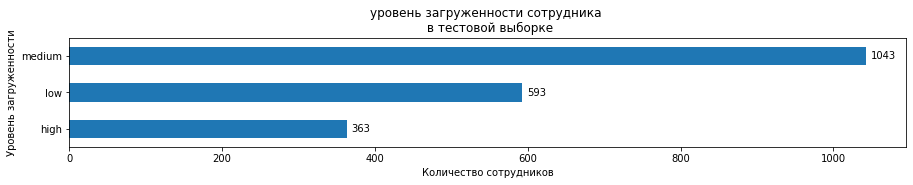

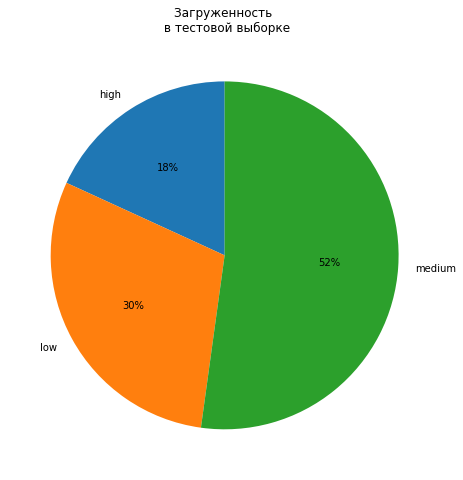

In [33]:
ax = test_features['workload'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='уровень загруженности сотрудника \n в тестовой выборке'
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    
plt.xlabel('Количество cотрудников')
plt.ylabel('Уровень загруженности')
plt.show()

ax = test_features.pivot_table(index='workload', values='id', aggfunc='count').reset_index()
plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['workload'], startangle=90, autopct = "%.0f%%")
plt.title('Загруженность \n в тестовой выборке')
plt.show()

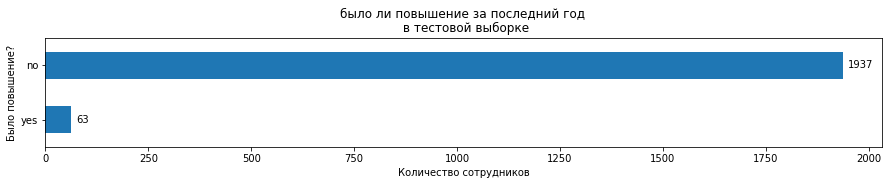

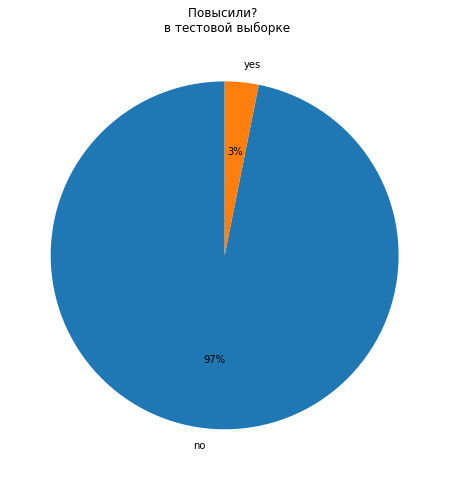

In [34]:
ax = test_features['last_year_promo'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='было ли повышение за последний год \n в тестовой выборке'
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    
plt.xlabel('Количество cотрудников')
plt.ylabel('Было повышение?')
plt.show()

ax = test_features.pivot_table(index='last_year_promo', values='id', aggfunc='count').reset_index()
plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['last_year_promo'], startangle=90, autopct = "%.0f%%")
plt.title('Повысили? \n в тестовой выборке')
plt.show()

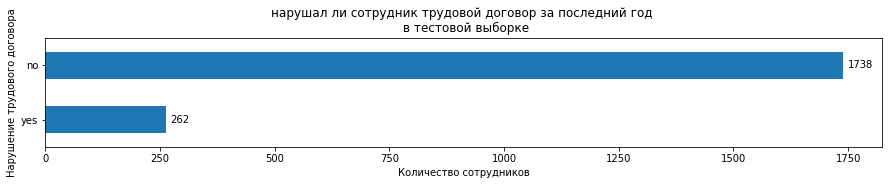

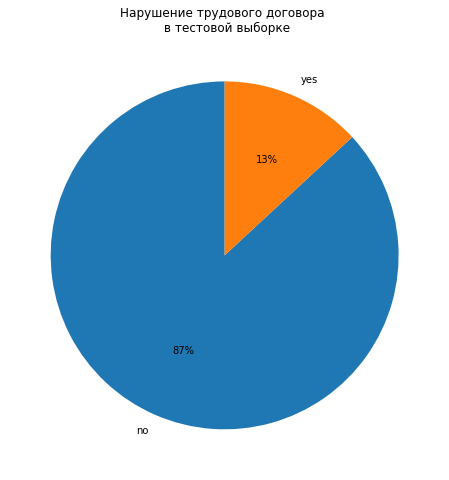

In [35]:
ax = test_features['last_year_violations'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='нарушал ли сотрудник трудовой договор за последний год \n в тестовой выборке'
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    
plt.xlabel('Количество cотрудников')
plt.ylabel('Нарушение трудового договора')
plt.show()

ax = test_features.pivot_table(index='last_year_violations', values='id', aggfunc='count').reset_index()
plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['last_year_violations'], startangle=90, autopct = "%.0f%%")
plt.title('Нарушение трудового договора \n в тестовой выборке')
plt.show()

Мы наблюдаем интересную картину.
Тестовая и тренировачная выборки не отличаются. (Вернее не отличаются так сильно, что бы можно было судить о некорректности данных)

1) длительность работы в компании (в годах) с годами равномерно падает. В этом есть смысл, поскольку мало кто задерживается на одном месте.

2) Самая частая оценка качества работы сотрудника, которую дал руководитель это 4, но и 3 ненамного меньше.

3) Ежемесячная зарплата сотрудника в среднем 34000. Но по медиане она равна 30000.

4) Целевой признак удовлетворенности имеет нормальное распределение с центром чуть-чуть выше середины (0.56). То есть пик находится в нейтральном состоянии.



5) 38% большая доля работает в отделе sales, а меньшая всего в hr 11%

6) Джунов и мидлов примерно поровну. 47 и 44. Сеньоров очень мало. 9%

7) Загруженность у большинства равна средней, низкая 30%, а высокая 18%

8) За последний год было повышено 120 сотрудников. То есть всего 3%

9) Что то много нарушений. 14% Интересно было бы узнать, что входит в нарушение трудового договора.



В данных наблюдаются небольшие выбросы. Но аномально высоких или низких значений нет. Все в пределах нормы и ошибок в данных нет. Все несоответсвия и дисбалансы обьяснимы.

#### Корреляция

Не понятно, почему в задании не указано сделать корреляционный анализ. А какие признаки мне тогда исползовать в шаге 4? Сделаю его хотя бы для себя и если надо будет - удалю. Использую phik (я его установил ёще в начале)

##### Корреляция целевого признака тренировочной выборки

In [36]:
phik_matrix_train = train_job_satisfaction_rate.phik_matrix(interval_cols=['salary', 'job_satisfaction_rate'])
display(phik_matrix_train['job_satisfaction_rate'])

/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable id is large: 4000. Are you sure this is not an interval variable? Analysis for pairs of variables including id can be slow.
  warnings.warn(


id                       1.000000
dept                     0.082086
level                    0.080620
workload                 0.056128
employment_years         0.325603
last_year_promo          0.190803
last_year_violations     0.560348
supervisor_evaluation    0.764364
salary                   0.165830
job_satisfaction_rate    1.000000
Name: job_satisfaction_rate, dtype: float64

Это пока не матрица, он будет позже для поиска мультиколлинеарности. Здесь просто исследование целевого признака.
(Примечание: это только тестовая выборка.)

С удовлетворенностью по убыванию коррелируют:

1) Оценка качества работы сотрудника, которую дал руководитель 0.764364 

    Тут 2 теории: 

    Теория 1. Либо оценка руководителя сильно влияет на мораль сотрудников, из-за чего их удовлетворенность работой падает, когда руководитель ставит им 1 балл из 5 и наоборот.

    Теория 2. Видимо качество работы напрямую влияет на удовлетворенность, и руководитель подмечает это.

2) нарушал ли сотрудник трудовой договор за последний год  0.560348

    Я не знаю, что сказать. Видимо, чем больше нарушений, тем меньше удовлетворенность? А почему? Это бинарный признак. С мультиколлинеарностью связано?

3) длительность работы в компании        0.325603

    Слабая корелляция и тут возможно нарушение причинно следственной связи. 
    Он удовлетворен работой, потому что долго работает в этой компании или он долго работает в этой компании потому что удовлетворен работой?


Остальные имеют слабую корреляцию 

было ли повышение за последний год 0.190803

ежемесячная зарплата сотрудника  0.165830 

отдел, в котором работает сотрудник 0.082659

уровень занимаемой должности 0.080753

уровень загруженности сотрудника 0.056128




##### Корреляция всех признаков тренировочной выборки

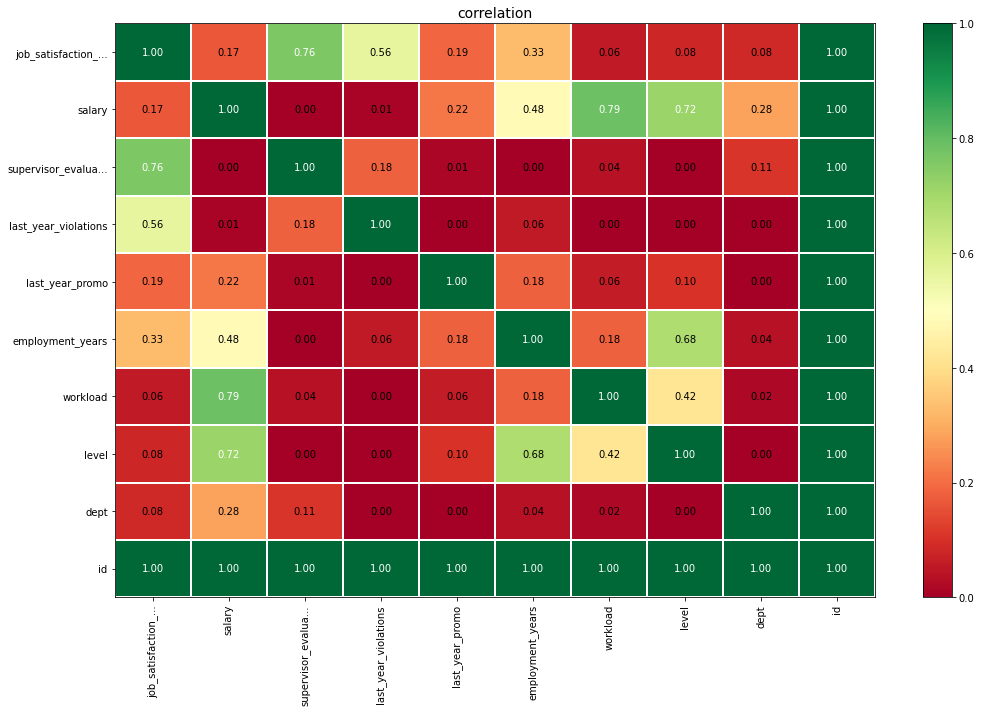

In [37]:
plot_correlation_matrix(
    phik_matrix_train.values,
    x_labels=phik_matrix_train.columns,
    y_labels=phik_matrix_train.index,
    vmin=0, vmax=1,
    figsize=(15, 10)
)

Никаких странностей не обнаружено. Все обьяснимо и поддается логике. Например связь зарплаты с должностью и загруженностью.

##### Графики зависимостей признаков тренировочной выборки

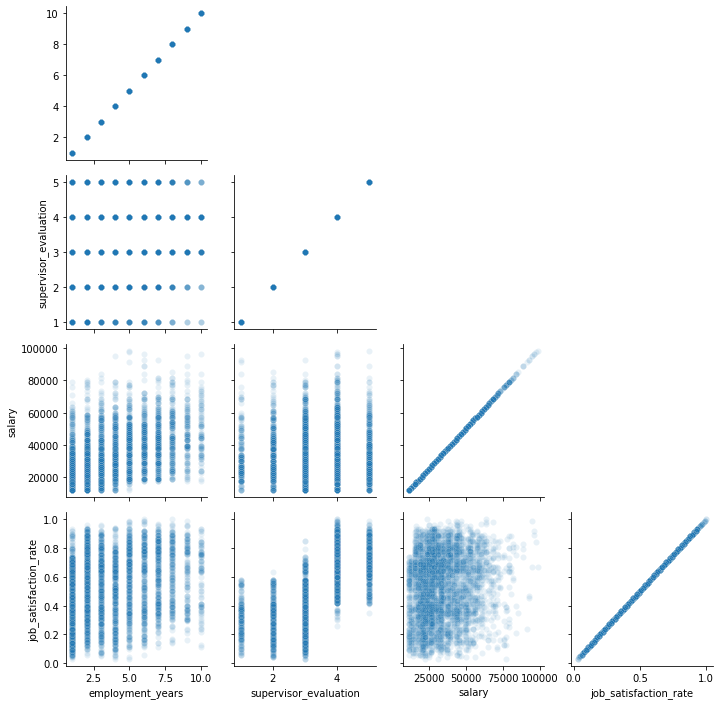

In [38]:
z_correl= sns.PairGrid(train_job_satisfaction_rate.drop('id', axis=1), diag_sharey=False, corner=True)
z_correl.map(sns.scatterplot, alpha=0.1)

plt.show()

#### Промежуточный вывод по шагу 3.


Данные нормально распределены не везде, но такова их специфика

Зачем надо было заранее распределять данные на выборки? Их не удобно анализировать, по два раза приходится это делать.
Сравнивать еще друг с другом. А почему тогда тренировочная выборка не разделена на целевой н нецелевые признаки? Но ладно.

### Шаг 4. Подготовка данных

Подготовку признаков выполните в пайплайне, дополнив пайплайн шагом предобработки. (?)





Работать буду с тренировочной выборкой. Удалю из неё id потому что он не нужен, а еще удалю целевой признак, что бы вынести его отдельно. 


Однако, таким же образом надо будет обработать и тестовую. Что бы, собственно, правильно тестирование провести.

In [39]:
isnull_pipe = Pipeline(
    [
        (
            'SimpleImputer',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
    ]
)
train_job_satisfaction_rate[['dept', 'level']] = isnull_pipe.fit_transform(train_job_satisfaction_rate[['dept', 'level']])
test_features[['dept', 'level', 'workload']] = isnull_pipe.fit_transform(test_features[['dept', 'level', 'workload']])

#### Подготовка признаков тренировочной выборки

In [40]:
train_job_satisfaction_rate_temp = train_job_satisfaction_rate.drop(['id'], axis=1)
print('Количество дубликатов в тренировочной:',train_job_satisfaction_rate_temp.duplicated().sum())



Количество дубликатов в тренировочной: 248


Понятно.

In [41]:
train_job_satisfaction_rate_temp = train_job_satisfaction_rate_temp.drop_duplicates().reset_index(drop=True)


In [42]:
X_train = train_job_satisfaction_rate_temp.drop(['job_satisfaction_rate'], axis=1)
y_train = train_job_satisfaction_rate_temp['job_satisfaction_rate']

#### Подготовка признаков тестовой выборки

К тестовой. Они уже разделены. Обьеденю для порядка, а потом дропну id

In [43]:
test_job_satisfaction_rate_temp = test_target_job_satisfaction_rate.merge(test_features, on='id')
print('Количество дубликатов в тестовой:',test_job_satisfaction_rate_temp.duplicated().sum())

Количество дубликатов в тестовой: 0


In [44]:
X_test = test_job_satisfaction_rate_temp.drop(['job_satisfaction_rate','id'], axis=1)
y_test = test_job_satisfaction_rate_temp['job_satisfaction_rate']


#### Проверка размерностей выборок

In [45]:
X_train.shape

(3752, 8)

In [46]:
X_test.shape

(2000, 8)

In [47]:
y_train.shape

(3752,)

In [48]:
y_test.shape

(2000,)

#### Кодировка выборок

При кодировании учитывайте особенности признаков и моделей и используйте как минимум два кодировщика.

In [49]:
ohe_columns = [
    'last_year_promo',
    'last_year_violations',
    'dept'
]
ord_columns = [
    'level',
    'workload'
]
num_columns = [
    'employment_years',
    'salary',
    'supervisor_evaluation'
]

In [50]:
ohe_pipe = Pipeline(
    [
        ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

In [51]:
ord_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ord', OrdinalEncoder(
        categories=[
            ['junior', 'middle', 'sinior'],
            ['low', 'medium', 'high']
        ],
        handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
])




In [52]:
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', StandardScaler(), num_columns)
     ],
    remainder='passthrough'
)



In [53]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

#### Промежуточный вывод по шагу 4


Данные готовы

### Шаг 5. Обучение моделей

Обучите как минимум две модели.


Ну, две так две.

#### Обучение моделей

Возьмите одну линейную модель, а в качестве второй — дерево решений. 

(какое дерево? мы непрерывный признак изучаем. Это не для дерева decision tree classifier). Добавлю KNeighborsRegressor.

А вместо DecisionTreeClassifier возьму DecisionTreeRegressor

In [54]:
param_grid = [
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(),'passthrough']  
    },
    
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)], #!
        'models__max_depth': range(1, 21),
        'models__max_features': range(1, 21),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    
    {
#        'models': [KNeighborsRegressor(n_jobs=-1, weights='distance')],
        'models': [KNeighborsRegressor()], #пусть будет
        'models__n_neighbors': range(5, 20), 
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']     
    }
    
]

##### SMAPE

Выбор делайте на основе новой метрики — SMAPE (англ. symmetric mean absolute percentage error, «симметричное среднее абсолютное процентное отклонение»). 



Метрика SMAPE вычисляется так:
    
SMAPE=100/n ∑n i=1 ((∣yi−yi^∣) / ((∣yi∣+∣y^i∣)/2))

yi — фактическое значение целевого признака для объекта с порядковым номером i в выборке;

yi^ - предсказанное значение целевого признака для объекта с порядковым номером i в выборке;

n — количество объектов в выборке;

∑n i=1 — сумма значений, полученная в результате операций, которые следуют за этим знаком, для всех объектов с порядковым номером от i до n в выборке.



https://en.wikipedia.org/wiki/Symmetric_mean_absolute_percentage_error

In [55]:
def smape(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # если 0
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / denominator
    
   
    diff[denominator == 0] = 0.0
    
    return 100 * np.mean(diff) #%

In [56]:
smaper = make_scorer(smape, greater_is_better=False)

<div class="alert alert-warning">
<font size="5"><b>Комментарий ревьюераV2</b></font>



Совет 🤔:


По умолчанию стоит greater_is_better =  True,  пусть будут подбираться такие гиперпараметры при которых чем хуже прогноз тем лучше. Видимо среди твоих гиперпараметров были такие при которых модель вообще не обучалась

In [57]:
kf_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

#### Модель

In [58]:
%%time

grid = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=kf_cv,
    scoring=smaper, 
    n_jobs=-1
)
grid.fit(X_train, y_train)

print('Лучшая модель:', grid.best_estimator_)
print ('Метрика лучшей модели на трен.выборке:', grid.best_score_*(-1))

Лучшая модель: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['last_year_promo',
                                                   'last_year_violations',
                                                   'dept']),
                                                 ('

Выберите лучшую модель и проверьте её качество.


#### Проверка на тестовой выборке.

In [59]:
grid_predictions = grid.predict(X_test)

print('smare тестовой выборки', smape(y_test, grid_predictions))

# Оценка качества модели по нашей особой метрике
if smape(y_test, grid_predictions) <= 15:
    print("Модель успешна")
else:
    print("Модель не успешна")

smare тестовой выборки 14.13968286322705
Модель успешна


В решении сохраните работу со всеми моделями, которые вы пробовали.

Уж не знаю, что тут сохранять. Из-за неправильного расчета метрики smare, у меня постоянно nan выходило или 23.70%


 Сделайте выводы.

#### Промежуточный вывод по шагу 5.

Я исползовал пайплайн, 3 кодировщика, ColumnTransformer.

И выбрал 3 модели. С помощью GridSearchCV выбрана лучшие модель и параметры (Модель DecisionTreeRegressor). Проверил качество с помощью SMAPE, величина которой  на тестовой выборке составила 14.81%.
По тз это считается успехом.

### Шаг 6. Оформление выводов


Задача выполнена. Теперь можно предсказывать удовлетворенность сотрудников на основании будущих данных.

Обучение моделей выдало дерево с max_depth=10, max_features=10,
Тестовая проверка с помощью smare была удовлетворительной.


#### Вывод о модели

Сделайте промежуточные выводы о том, какая модель справилась лучше и почему.

По моему мнению, дерево оказалось лучше из-за того, что оно может справляться с такими сложными и специфическими параметрами, как те, что я выявил в 3 шаге. Будь они более обыкновенными (с нормальным распределением, без выбросов, без такой мудреной классификации, а так же с равным отношением), то могла бы и выйти лучшей линейная регрессия.

## Задача 2: предсказание увольнения сотрудника из компании
Для этой задачи вы можете использовать те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: это quit — увольнение сотрудника из компании.

### Шаг 1. Загрузка данных

Загрузите данные из файлов:


#### Тренировочная выборка:

train_quit.csv


In [60]:
train_quit = pd.read_csv('/datasets/train_quit.csv')
display(train_quit.head())
train_quit.info()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


#### Входные признаки тестовой выборки те же, что и в прошлой задаче:

test_features.csv


In [61]:
display(test_features.head()) #выведу их все же для ознакомления и сравнения.
test_features.info()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   2000 non-null   object
 2   level                  2000 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


#### Целевой признак тестовой выборки:

test_target_quit.csv

In [62]:
test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')
display(test_target_quit.head())
test_target_quit.info()

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


#### Промежуточные выводы по шагу 1.

В новых датасетах пропусков нет.
Типы данных в колонках менять не надо. Названия колонок менять не нужно.
Данные соответствуют описанию.

### Шаг 2. Предобработка данных

Изучите данные и при необходимости выполните предобработку. 

In [63]:
test_target_quit.head()

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


In [64]:
print('уникальные значения в колонках тренировочной выборки')
print('В dept:', (train_quit['dept'].unique()))
print('В level:', (train_quit['level'].unique()))
print('В workload:', (train_quit['workload'].unique()))
print('В employment_years:', (train_quit['employment_years'].unique()))
print('В last_year_promo:', (train_quit['last_year_promo'].unique()))
print('В last_year_violations:', (train_quit['last_year_violations'].unique()))
print('В supervisor_evaluation:', (train_quit['supervisor_evaluation'].unique()))
print('В quit (целевой признак):', (train_quit['quit'].unique()))

уникальные значения в колонках тренировочной выборки
В dept: ['sales' 'purchasing' 'marketing' 'technology' 'hr']
В level: ['middle' 'junior' 'sinior']
В workload: ['high' 'medium' 'low']
В employment_years: [ 2  5  1  8  4  7  3  9  6 10]
В last_year_promo: ['no' 'yes']
В last_year_violations: ['no' 'yes']
В supervisor_evaluation: [4 1 3 5 2]
В quit (целевой признак): ['no' 'yes']


In [65]:
print('уникальные значения в целевом признаке тестовой выборки')
print('В quit:', (test_target_quit['quit'].unique()))

уникальные значения в целевом признаке тестовой выборки
В quit: ['yes' 'no']


Пробелов и nan нет, а входные признаки тестовой выборки были обработаны в задаче 1.

Если есть пропуски, заполните их в пайплайне.

In [66]:
print('Неявных дубликатов в train_quit', train_quit.isna().sum().sum())
print('Неявных дубликатов в test_features', test_features.isna().sum().sum())
print('Неявных дубликатов в test_target_quit', test_target_quit.isna().sum().sum())

Неявных дубликатов в train_quit 0
Неявных дубликатов в test_features 0
Неявных дубликатов в test_target_quit 0


In [67]:
print('Явных дубликатов в train_quit:', train_quit.duplicated().sum())
print('Явных дубликатов в test_features:', test_features.duplicated().sum())
print('Явных дубликатов в test_target_quit:', test_target_quit.duplicated().sum())

Явных дубликатов в train_quit: 0
Явных дубликатов в test_features: 0
Явных дубликатов в test_target_quit: 0


В заполнении пропусков пайплайном нет нужды. Пропуски отсутствуют

#### Промежуточный вывод по шагу 2.
Данные не нуждаются в переименовывании или любой другой предобработке.

### Шаг 3. Исследовательский анализ данных

А нужно ли снова исследовать признаки, которые исследовались в 1-ой задаче?

#### Проведите исследовательский анализ данных.

Выведу описание данных и сравню их с этим шагом из первой задачей.

In [68]:
display(train_quit.describe().T)
display(test_features.describe().T)
display(test_target_quit.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,4000.0,552099.28375,260158.031387,100222.0,327785.75,546673.0,781497.75,999915.0
employment_years,4000.0,3.70150,2.541852,1.0,2.00,3.0,6.00,10.0
supervisor_evaluation,4000.0,3.47475,1.004049,1.0,3.00,4.0,4.00,5.0
salary,4000.0,33805.80000,15152.415163,12000.0,22800.00,30000.0,43200.00,96000.0


,count,mean,std,min,25%,50%,75%,max
id,2000.0,552765.2135,253851.326129,100298.0,339052.0,550793.0,765763.75,999029.0
employment_years,2000.0,3.6665,2.537222,1.0,1.0,3.0,6.00,10.0
supervisor_evaluation,2000.0,3.5265,0.996892,1.0,3.0,4.0,4.00,5.0
salary,2000.0,34066.8000,15398.436729,12000.0,22800.0,30000.0,43200.00,96000.0


,count,mean,std,min,25%,50%,75%,max
id,2000.0,552765.2135,253851.326129,100298.0,339052.0,550793.0,765763.75,999029.0


Проведу исследование нового признака. Он же целевой.
quit - Категориальный бинарный признак, а потому построю гистограмму.

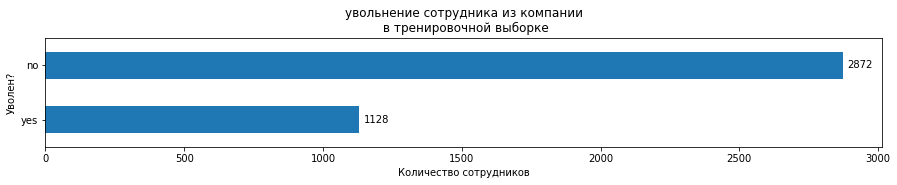

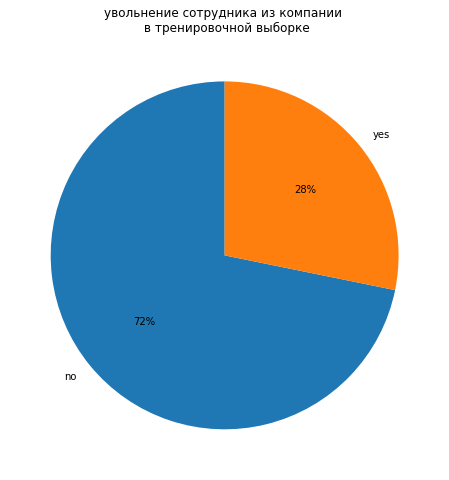

In [69]:
ax = train_quit['quit'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='увольнение сотрудника из компании\n в тренировочной выборке'
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    
plt.xlabel('Количество cотрудников')
plt.ylabel('Уволен?')
plt.show()

ax = train_quit.pivot_table(index='quit', values='id', aggfunc='count').reset_index()
plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['quit'], startangle=90, autopct = "%.0f%%")
plt.title('увольнение сотрудника из компании \n в тренировочной выборке')
plt.show()

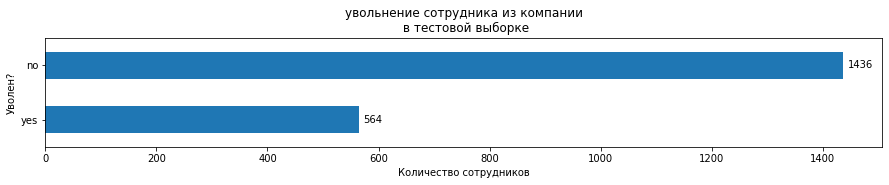

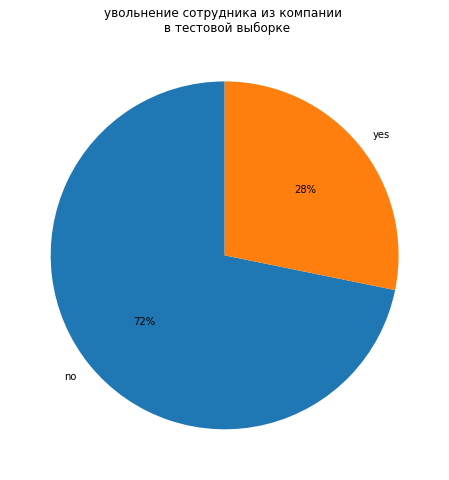

In [70]:
ax = test_target_quit['quit'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='увольнение сотрудника из компании\n в тестовой выборке'
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
    
plt.xlabel('Количество cотрудников')
plt.ylabel('Уволен?')
plt.show()

ax = test_target_quit.pivot_table(index='quit', values='id', aggfunc='count').reset_index()
plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['quit'], startangle=90, autopct = "%.0f%%")
plt.title('увольнение сотрудника из компании \n в тестовой выборке')
plt.show()

Все нормально. Данные правильно разделены на выборки.


Вывод. 28% увольняются. Сами уходят. Даже не знаю, нормально ли это для такой компании, но раз руководитель считает это проблемой, то значит это много.

In [71]:
phik_matrix_train = train_quit.phik_matrix(interval_cols=['salary'])
display(phik_matrix_train['quit'])

/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable id is large: 4000. Are you sure this is not an interval variable? Analysis for pairs of variables including id can be slow.
  warnings.warn(


id                       1.000000
dept                     0.000000
level                    0.312799
workload                 0.132243
employment_years         0.659093
last_year_promo          0.157370
last_year_violations     0.185071
supervisor_evaluation    0.245489
salary                   0.564154
quit                     1.000000
Name: quit, dtype: float64

длительность работы в компании (в годах)                               0.659093

Ну, с ненасиженного места уйти проще, чем человеку, который там уже карьеру себе сделал. Покидать эту должность будет минимум некомфортно и ресурсозатратно.

ежемесячная зарплата сотрудника                                        0.564154

Все просто. Нашел работу где платят больше и все. Переманили. Или работник подумал, что его силы и время, затраченные на его труд не окупаются. Это тоже повод для увольнения.

Остальные имеют слабую кореляцию

уровень занимаемой должности                                           0.312799

оценка качества работы сотрудника, которую дал руководитель            0.245489

показывает, нарушал ли сотрудник трудовой договор за последний год     0.185071

показывает, было ли повышение за последний год                         0.157370

уровень загруженности сотрудника                                       0.132243

отдел, в котором работает сотрудник                                    0.000000

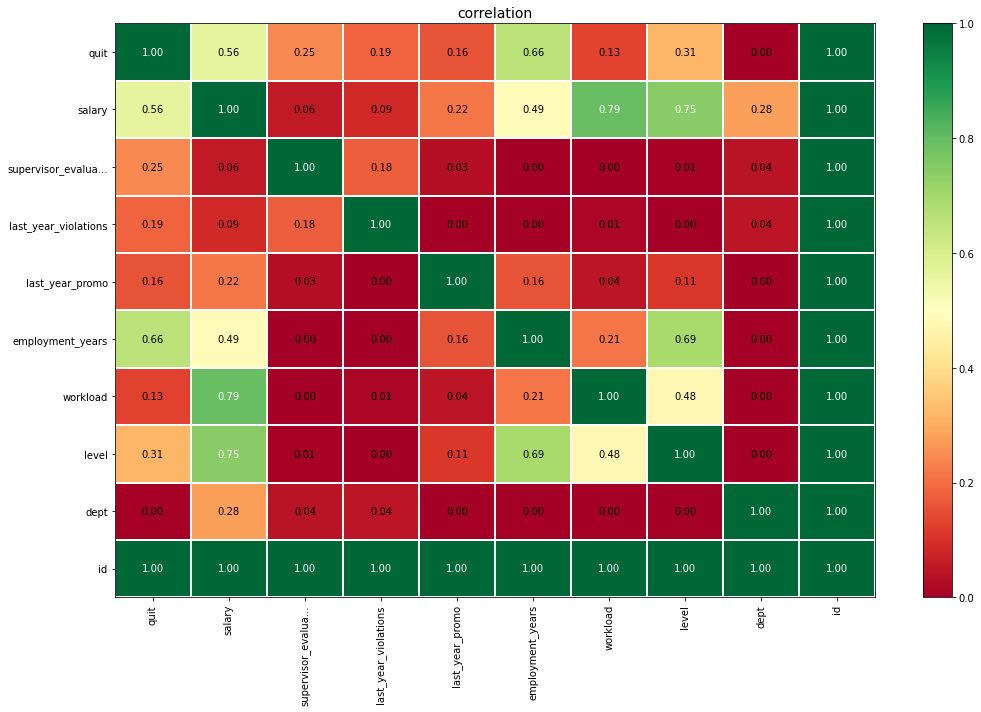

In [72]:
plot_correlation_matrix(
    phik_matrix_train.values,
    x_labels=phik_matrix_train.columns,
    y_labels=phik_matrix_train.index,
    vmin=0, vmax=1,
    figsize=(15, 10)
)



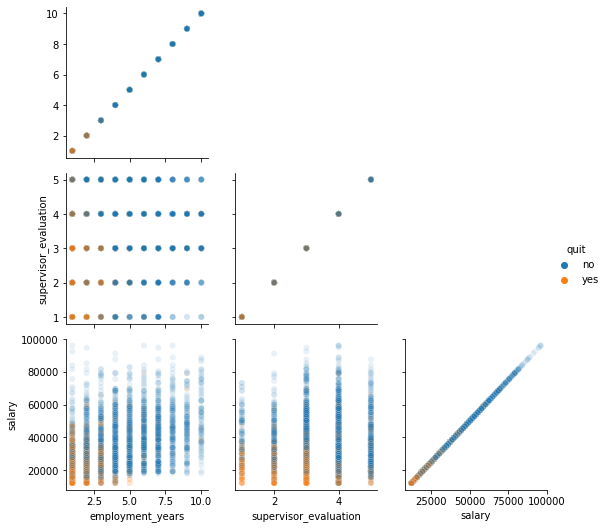

In [73]:
z_correl= sns.PairGrid(train_quit.drop('id', axis=1), diag_sharey=False, corner=True, hue='quit')
z_correl.map(sns.scatterplot, alpha=0.1)
z_correl.add_legend()
plt.show()

Никаких противоречий. Все в пределах логики. Чем меньше сотрудник работает, зарабатывает и старается, тем выше шанс его ухода.

#### Составьте портрет «уволившегося сотрудника».

Например, можно узнать, в каком отделе с большей вероятностью работает уволившийся сотрудник и какой у него уровень загруженности. Также можно сравнить среднее значение зарплаты ушедших сотрудников с теми, кто остался в компании.


Отдел по моему мнению (и по уровню корреляции) повлиял бы на портрет «уволившегося сотрудника» минимально. А вот среднее значение зарплаты ушедших сотрудников с теми, кто остался в компании звучит более интересно.

In [74]:
# Отберем уволившихся сотрудников
not_loyal_train_quit = train_quit.query('quit == "yes"')
loyal_train_quit = train_quit.query('quit == "no"')
not_loyal_train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
5,699916,sales,junior,low,1,no,yes,3,18000,yes
9,613206,technology,middle,medium,2,no,no,3,45600,yes
24,468145,technology,junior,medium,2,no,no,3,30000,yes
25,982346,marketing,junior,medium,3,no,no,3,30000,yes


In [75]:
display("Отдел ушедших сотрудников", not_loyal_train_quit['dept'].value_counts())
display("Отдел лояльных сотрудников", loyal_train_quit['dept'].value_counts())


display("Процент ухода сотрудников из того или иного отдела", not_loyal_train_quit['dept'].value_counts() / (loyal_train_quit['dept'].value_counts() + not_loyal_train_quit['dept'].value_counts()))

'Отдел ушедших сотрудников'

sales         407
technology    276
purchasing    166
marketing     163
hr            116
Name: dept, dtype: int64

'Отдел лояльных сотрудников'

sales         1031
technology     652
purchasing     422
marketing      419
hr             348
Name: dept, dtype: int64

'Процент ухода сотрудников из того или иного отдела'

sales         0.283032
technology    0.297414
purchasing    0.282313
marketing     0.280069
hr            0.250000
Name: dept, dtype: float64

Выбивающихся значений нет. Из отделов ушло от 25% до 29%. 

Можно предположить, что с отделом технологий что то не так, но так как количество сотрудников в отделах далеко не одинаковое, то это просто можно списать на погрешность.

Опять таки. Без выбивающихся значений. Отдел - наименьшая из проблем увольнения сотрудников. Теперь мы перейдем не к зарплате, как в тз, а пройдемся по остальным признакам, для полноты портрета «уволившегося сотрудника».

In [76]:
display("Уровень ушедших сотрудников", not_loyal_train_quit['level'].value_counts())
display("Уровень лояльных сотрудников", loyal_train_quit['level'].value_counts())



'Уровень ушедших сотрудников'

junior    1003
middle     108
sinior      17
Name: level, dtype: int64

'Уровень лояльных сотрудников'

middle    1586
junior     946
sinior     340
Name: level, dtype: int64

Ну это же джуниоры. Может они на подработку, стажировку или по ошибке пришли.
Мидлы так же могут уйти по своим делам или уйти, осваивать что-то новое. Или из-за лучшей зп.

Как я описывал в выводе выше - с ненасиженного места легче уйти. Уровень коррелирует с временем работы.

В общем тут много можно сделать выводов.

In [77]:
display("Нагрузка ушедших сотрудников",not_loyal_train_quit['workload'].value_counts())

display("Нагрузка лояльных сотрудников", loyal_train_quit['workload'].value_counts())

'Нагрузка ушедших сотрудников'

low       519
medium    488
high      121
Name: workload, dtype: int64

'Нагрузка лояльных сотрудников'

medium    1630
low        689
high       553
Name: workload, dtype: int64

Причина увольнения не в высокой нагрузке. Больше всего уволилось сотрудников с низким уровнем нагрузки. И это даже не учитывая того, что сотрудников с низким уровнем нагрузки не большинство.

Обьяснение наверняка лежит в том, что нагрузка коррелирует с зп, но до неё мы еще дойдем. Рано делать выводы.

In [78]:
display("Повысили ли уволенного сотрудников?",not_loyal_train_quit['last_year_promo'].value_counts())
display("Повысили ли лояльных сотрудников?",loyal_train_quit['last_year_promo'].value_counts())

'Повысили ли уволенного сотрудников?'

no     1127
yes       1
Name: last_year_promo, dtype: int64

'Повысили ли лояльных сотрудников?'

no     2760
yes     112
Name: last_year_promo, dtype: int64

Причину и следствие тут очень легко перепутать

Он ушел, потому что не повысили?
Или его не повысили, потому что руководитель чувствовал по его другим данным, что он скоро уйдет?

Хотя обе этих причины не взаимоисключают друг друга. Может даже синергируют.



In [79]:
display("Нарушали трудовой договор уволенные сотрудники?",not_loyal_train_quit['last_year_violations'].value_counts())
display("Нарушали трудовой договор лояльные сотрудники?",loyal_train_quit['last_year_violations'].value_counts())



'Нарушали трудовой договор уволенные сотрудники?'

no     900
yes    228
Name: last_year_violations, dtype: int64

'Нарушали трудовой договор лояльные сотрудники?'

no     2555
yes     317
Name: last_year_violations, dtype: int64

Доля ушедших сотрудников нарушивших трудовой договор по сравнению с уволившимися выше.

In [80]:
display("Как оценивал работу уволившихся руководитель",not_loyal_train_quit['supervisor_evaluation'].value_counts())
display("Как оценивал работу лояльных руководитель",loyal_train_quit['supervisor_evaluation'].value_counts())


display("Как оценивал работу уволившихся руководитель в среднем",not_loyal_train_quit['supervisor_evaluation'].mean())
display("Как оценивал работу лояльных руководитель в среднем",loyal_train_quit['supervisor_evaluation'].mean())

'Как оценивал работу уволившихся руководитель'

3    523
4    286
2    164
1     95
5     60
Name: supervisor_evaluation, dtype: int64

'Как оценивал работу лояльных руководитель'

4    1368
3     710
5     460
2     227
1     107
Name: supervisor_evaluation, dtype: int64

'Как оценивал работу уволившихся руководитель в среднем'

3.0460992907801416

'Как оценивал работу лояльных руководитель в среднем'

3.643105849582173

Однако по оценке руководителя, такие работники выполняли свою работу ненамного хуже, чем лояльные.

In [81]:
print('Среднее время работы ушедших сотрудников', not_loyal_train_quit['employment_years'].mean())
print('Среднее время работы лояльных сотрудников', loyal_train_quit['employment_years'].mean())

Среднее время работы ушедших сотрудников 1.8448581560283688
Среднее время работы лояльных сотрудников 4.430710306406685


Выводы приведенные чуть выше укрепляются.

In [82]:
print('Средняя ЗП уволившихся сотрудников:', not_loyal_train_quit['salary'].median())
print('Средняя ЗП лояльных сотрудников:', loyal_train_quit['salary'].median())
print('Средняя разница в зарплатах:', loyal_train_quit['salary'].median() - not_loyal_train_quit['salary'].median())

Средняя ЗП уволившихся сотрудников: 22800.0
Средняя ЗП лояльных сотрудников: 34800.0
Средняя разница в зарплатах: 12000.0


Деньги. На самом деле средним значением их считать нельзя. А то 'среднем по больнице' выходит, что они все зарабатывают одинаковую сумму.

Но и медианы порой бывает недостаточно. Экономические расчеты куда сложнее. Но даже по такому портету видно, что:

Уволившийся в общей массе работает в отделе sales, но индивидуально охотнее уволится из technology
Он джуниор с низкой нагрузкой, который работал 1 год и 9 месяцев в компании. С этими параметрами он зарабатывал 22800.0, пока остальные зарабатывали на 12000.0 больше. Его за последний год не повысили(потому он и джуниор). Скорее всего он нарушал трудовой договор. И работал на троечку.

####  Визуализизация и сравнение распределения признака job_satisfaction_rate  для ушедших и оставшихся сотрудников

Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Проверьте это утверждение: визуализируйте и сравните распределения признака job_satisfaction_rate для ушедших и оставшихся сотрудников. Используйте данные с обоими целевыми признаками тестовой выборки.

Ок.Это логичное утверждение. Вернем целевой признак Удовлетворенность из первой задачи и сравним их распределение.

Для этого объединим тестовые выборки содержащие целевые признаки друг с другом.

Но подходят ли эти две тестовые выборки по id?

In [83]:
analithyc_teor_data = (test_target_job_satisfaction_rate.merge(test_target_quit, on="id").reset_index(drop=True))
analithyc_teor_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
 2   quit                   2000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 47.0+ KB


Да, все нормально. Можно работать.

In [84]:
not_loyal_analithyc_teor_data = analithyc_teor_data.query('quit == "yes"')
loyal_analithyc_teor_data = analithyc_teor_data.query('quit == "no"')

not_loyal_analithyc_teor_data.head()

,id,job_satisfaction_rate,quit
2,418490,0.60,yes
4,826430,0.08,yes
20,508688,0.58,yes
29,343440,0.35,yes
30,622918,0.77,yes


Теперь по тз, я должен это визуализировать.

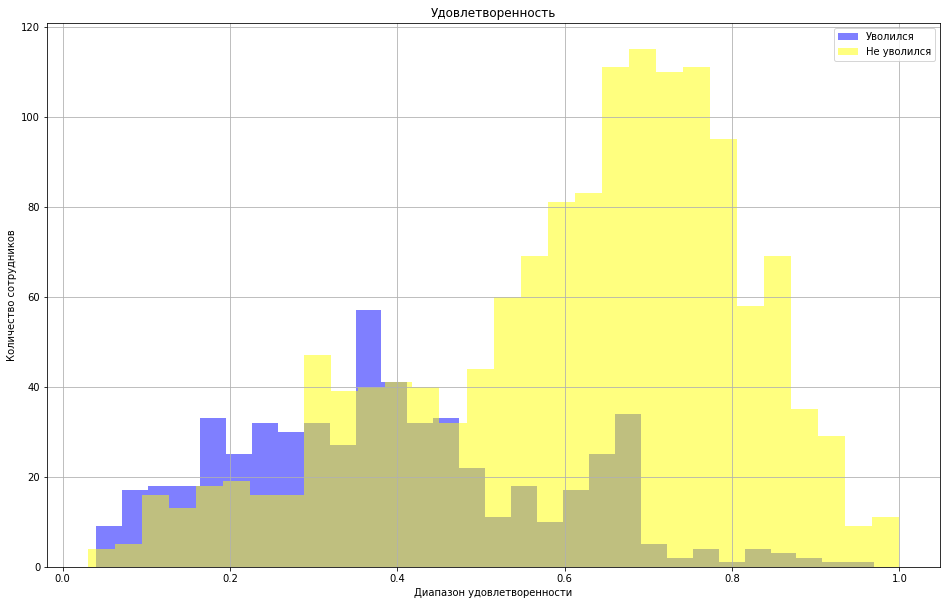

In [85]:
plt.figure(figsize=(16, 10))

plt.hist(not_loyal_analithyc_teor_data[not_loyal_analithyc_teor_data['quit'] == 'yes']['job_satisfaction_rate'], 
         bins=30, alpha=0.5, label='Уволился', color='blue')

plt.hist(loyal_analithyc_teor_data[loyal_analithyc_teor_data['quit'] != 'yes']['job_satisfaction_rate'], 
         bins=30, alpha=0.5, label='Не уволился', color='yellow')

# Заголовок и метки осей
plt.title('Удовлетворенность')
plt.xlabel('Диапазон удовлетворенности')
plt.ylabel('Количество сотрудников')
plt.legend()


plt.grid(True)
plt.show()

Оба распределения нормальные. Это хорошо. 

Пик удовлетворенности уволившихся находится до 0.5, а удовлетворенность лояльных сотрудников выше среднего.


Можно заметить еще одно пиковое распределение уволившихся, на 0.7.

Сравнивая распределения, видно, что утверждения аналитиков имеет смысл. И вот подтверждение.

#### Промежуточный вывод по шагу 3.

Признаки были верно распределены.

Процент уволившихся равняется 28%

Так же был составлен портрет "уволившегося сотрудника"

И в конце я сравнил уволившихся и лояльных сотрудников по признаку удовлетворенности, визуализировав это.

### Шаг 4. Добавление нового входного признака

Допустим, job_satisfaction_rate и quit действительно связаны и вы получили необходимое значение метрики в первой задаче. 

Ну допустим. Добавим сначала в тестовую.

In [86]:
train_job_satisfaction_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   4000 non-null   object 
 2   level                  4000 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


In [87]:
train_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


In [88]:
peremennaya = train_quit.merge(train_job_satisfaction_rate[['id', 'job_satisfaction_rate']], on='id', how='left')

peremennaya.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   4000 non-null   object 
 2   level                  4000 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   quit                   4000 non-null   object 
 10  job_satisfaction_rate  0 non-null      float64
dtypes: float64(1), int64(4), object(6)
memory usage: 375.0+ KB


Так, случилось непредвиденное обстоятельство. У train_quit и train_job_satisfaction_rate вообще нет общих id.

Почему? Почему в тестовых есть, а в тренировочных нет?

Тогда добавьте job_satisfaction_rate, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.

А. Предсказать нужно моей лучшей моделью из первой задачи?

grid.best_estimator_

In [89]:
train_quit['job_satisfaction_rate'] = grid.best_estimator_.predict(train_job_satisfaction_rate)
train_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   4000 non-null   object 
 2   level                  4000 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   quit                   4000 non-null   object 
 10  job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 343.9+ KB


Непредвиденное обстоятельство устранено. Тренировочная выборка дополнена. С тестовой проблем таких нет. Там все id cовпадают.

In [90]:
test_features = test_features.merge(test_target_job_satisfaction_rate[['id', 'job_satisfaction_rate']], on='id', how='left')

test_features.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   dept                   2000 non-null   object 
 2   level                  2000 non-null   object 
 3   workload               2000 non-null   object 
 4   employment_years       2000 non-null   int64  
 5   last_year_promo        2000 non-null   object 
 6   last_year_violations   2000 non-null   object 
 7   supervisor_evaluation  2000 non-null   int64  
 8   salary                 2000 non-null   int64  
 9   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 171.9+ KB


In [91]:
test_target_quit.info()# для сравнения

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


#### Промежуточный вывод по шагу 4.

Данные были дополнены новым признаком. С тестовыми данными проблем не вознико.

А вот тренировочные пришлось предсказывать по модели из первой задачи, так как id не совпадали.

Такой метод ухудшит работу моей второй модели в будущем, потому что она частично будет предсказывать по предсказаниям.

Это удручает. Но если бы я просто добавил удовлетворенность не по id, а просто так, то все бы просто стало бессмысленным.

Был ли другой исход?

### Шаг 5. Подготовка данных

Подготовьте признаки так же, как и в первой задаче: выполните подготовку в пайплайне, дополнив пайплайн предобработки. При кодировании учитывайте особенности признаков и моделей и используйте как минимум два кодировщика.

Сделаю так, для удобства.

In [92]:
train_2 = train_quit 
X_test_2 = test_features 
y_test_2 = test_target_quit

In [93]:
labelencoder = LabelEncoder() #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [94]:
train_2['quit'] = labelencoder.fit_transform(train_2['quit'])

#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [95]:
train_2_temp = train_2.drop(['id'], axis=1)
print('Количество дубликатов в тренировочной 2:',train_2_temp.duplicated().sum())

Количество дубликатов в тренировочной 2: 9


Понятно.

In [96]:
train_2_temp = train_2_temp.drop_duplicates().reset_index(drop=True)

In [97]:
X_train_2 = train_2_temp.drop(['quit'], axis=1)
y_train_2 = train_2_temp['quit']

Cейчас я обьединю тестовые данные (X_test_2 и y_train_2), по id, так как иначе на тесте модели мне выдаст метрику ниже 50.

In [98]:
test_2_temp = pd.merge(X_test_2, y_test_2, on='id', how='inner')


test_2_temp.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   dept                   2000 non-null   object 
 2   level                  2000 non-null   object 
 3   workload               2000 non-null   object 
 4   employment_years       2000 non-null   int64  
 5   last_year_promo        2000 non-null   object 
 6   last_year_violations   2000 non-null   object 
 7   supervisor_evaluation  2000 non-null   int64  
 8   salary                 2000 non-null   int64  
 9   job_satisfaction_rate  2000 non-null   float64
 10  quit                   2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 187.5+ KB


In [99]:
test_2_temp['quit'] = labelencoder.transform(test_2_temp['quit'])
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [100]:
test_2_temp = test_2_temp.drop(['id'], axis=1)
print('Количество дубликатов в тестовой 2:',test_2_temp.duplicated().sum())

Количество дубликатов в тестовой 2: 74


In [101]:
test_2_temp = test_2_temp.drop_duplicates().reset_index(drop=True)

In [102]:
X_test_2 = test_2_temp.drop(['quit'], axis=1)
y_test_2 = test_2_temp['quit']

In [103]:
X_train_2.shape

(3991, 9)

In [104]:
y_train_2.shape

(3991,)

In [105]:
X_test_2.shape

(1926, 9)

In [106]:
y_test_2.shape

(1926,)

Так как мы добавили новый признак, и он job_satisfaction_rate (float64), который ныне не является целевым, то он пойдет в исследование.

Теперь надо просто создать все заного с этим новым признаком. Отмечу двойкой.

Он пойдет в num_columns ('employment_years', 'supervisor_evaluation', 'salary')

In [107]:
ohe_columns_2 = [
    'last_year_promo',
    'last_year_violations',
    'dept'
]
ord_columns_2 = [
    'level',
    'workload'
]
num_columns_2 = [
    'employment_years',
    'salary',
    'supervisor_evaluation'
    ,
    'job_satisfaction_rate' #
]

In [108]:
ohe_pipe_2 = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        )
    ]
)

In [109]:
ord_pipe_2 = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'sinior'], 
                    ['medium', 'low', 'high']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [110]:
data_preprocessor_2 = ColumnTransformer(
    [
        ('ohe', ohe_pipe_2, ohe_columns_2),
        ('ord', ord_pipe_2, ord_columns_2),
        ('num', MinMaxScaler(), num_columns_2)
    ], 
    remainder='passthrough'
)

In [111]:
pipe_final_2 = Pipeline([
    ('preprocessor', data_preprocessor_2),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])


#### Промежуточный вывод по шагу 5

Данные подготовлены.
В пайплайн добавлен новый признак.
А на счет использования как минимум двух кодировщиков, то кодирование с прошлого раза не поменялось, а просто дополнилось. Так уже есть 2 и более кодировщиков. Главное входные переменные и новый пайплайн теперь не перепутать. Я их отметил двойкой.



Можно ли было использовать старые параметры, не создавая новых?
Бритва Оккама и прочее?

### Шаг 6. Обучение модели

Обучите как минимум три модели. Как минимум для двух из них подберите гиперпараметры. Проверьте качество лучшей модели.
Метрика оценки качества в этой задаче — ROC-AUC. Критерий успеха: ROC-AUC ≥ 0.91 на тестовой выборке. Напомним: отбор признаков часто помогает улучшить метрику.

In [112]:
param_grid_2 = [
    
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(),'passthrough']   
    },
    {
        'models': [DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 4),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(),'passthrough']  
    },
    {
        'models': [LogisticRegression(penalty='elasticnet' ,class_weight='balanced',solver='saga', random_state=RANDOM_STATE)],
        'models__C': range(1,3),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(),'passthrough']  
    },
    {
        'models': [SVC(class_weight='balanced', probability=True,random_state=RANDOM_STATE)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(),'passthrough']  

    }
    ]


In [113]:
%%time

grid_2 = GridSearchCV(
    pipe_final_2, 
    param_grid=param_grid_2, 
    cv=5,
    scoring='roc_auc', #по тз
    n_jobs=-1
)

grid_2.fit(X_train_2, y_train_2)




print('Лучшая модель и её параметры:', grid_2.best_estimator_)
print ('Метрика лучшей модели на трен.выборке:', grid_2.best_score_)

/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.9/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/conda/lib/python3.9/site-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/opt/conda/lib/python3

Лучшая модель и её параметры: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['last_year_promo',
                                                   'last_year_violations',
                                                   'dept']),
                                    

In [ ]:
grid_predictions_2 = grid_2.predict_proba(X_test_2)[:,1]

print('ROC-AUC тестовой выборки', roc_auc_score(y_test_2, grid_predictions_2))

# Оценка качества модели по метрике ROC-AUC 
if roc_auc_score(y_test_2, grid_predictions_2) >= 0.91:
    print("Модель успешна")
else:
    print("Модель не успешна")
    


~наконец-то~ 

И таким образом я закончил работу над второй задачей и обучил модель предсказывать, покинет ли сотрудник компанию или нет. 

### Шаг 7. Выводы


Ориентируясь на новый признак, и используя для высчитывания этого признака другую модель, я смог придти к успешным результатам.

Модель достаточно хороша, по моему мнению. Но её так же можно и улучшить. К примеру, убрав из неё некоторые признаки. Если это и не добавит ей точности, то хотя бы ускорит.

#### Выводы о модели

Лучшей моделью для этой задачи оказалось SVC (91%). Support Vector Classifier

Нам надо было предсказать только два результата. Уйдет или нет.

Но данные в выборках были довольно хаотичными.
Несмотря на то, что я расчитывал на LogisticRegression, добавляя в неё разные параметры, SVC все равно лучше. Может она оказалась более устойчивой.

# Общий вывод

Сформулируйте общий вывод:


### Опишите задачу;
Задача 1 - предсказать уровень удовлетворённости сотрудника
Задача 2 - разработка решения для предотвращения оттока сотрудников.


Мне предоставлено три датафрейма.
В них были странены дубликаты и изменены типы данных. 
Проведен исследовательский анализ с построением графиков. 
Создан пайплайн для подготовки этих данных к обучению модели.

Для предсказания удовлетворенности работой выбрана модель DecisionTreeRegressor (random_state=42) с метрикой SMAPE (14.13968286322705)

Была подтверждена её пригодность.

Эта модель позволила получить прогнозные значения, которые были добавлены как новый признак для следующей задачи.

Задача 2 - разработка решения для предотвращения оттока сотрудников.

Было предоставлено 2 новых датафрейма, но работать надо было не только с ними. Эта задача отчасти прямое продолжение первой

Исследовательский анализ показал, что данные достоверны, выбросов нет, утечек целевого признака не обнаружено. Подготовка данных включала обработку пропусков и другую обработку

На этот раз была выбрана модель SVC (random_state=42). Её показатель равен 91%.

Модель предсказывает, уйдет ли сотрудник.

(непонятно, правда, почему данные я получил уже в разделенном на выборки виде)

### опишите все этапы работы;



Исследование было разделено на несколько этапов:

1. Загрузка и подготовка данных

job_X_train

job_X_test

job_y_test

В этих данных обнаружилось с десяток пропусков и опечатка в названии должности senior. В описании сказано, что Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли. 

А потому такие данные я считаю хорошими, потому что ошибок в них мало, несмотря на такие условия.
2. Предобработка данных

Заменили пустые строки (" ") из данных на пропущенные значения
А затем избавились от пропущенных значений пайплайном.

3. Исследовательский анализ данных
Мало опытных сотрудников.

Оценка качества работы сотрудника cильно зависит от удовлетворенности было выдвинуто 2 теории.
Теория 1. Либо оценка руководителя сильно влияет на мораль сотрудников, из-за чего их удовлетворенность работой падает, когда руководитель ставит им 1 балл из 5 и наоборот.
Теория 2. Видимо качество работы напрямую влияет на удовлетворенность, и руководитель подмечает это.

Нарушал ли сотрудник трудовой договор зависит от удовлетворенности. Видимо за нарушения был какой-то штраф, выговор или лишение премии. А может и все сразу.
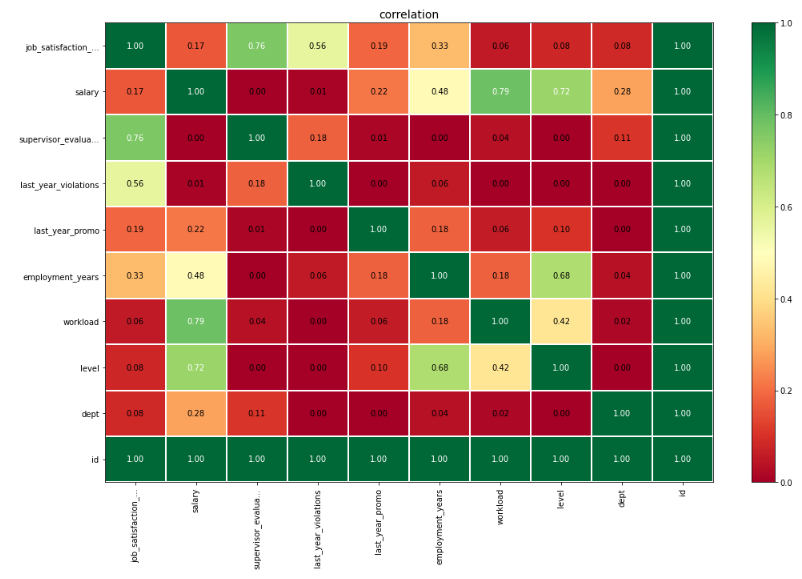

4. Подготовка признаков
При кодировании были учтены особенности признаков и моделей. Было использовано несколько кодировщиков.


5. Обучение моделей

SMAPE пересоздавалась несколько раз, для наиболее оптимального использования.

После перебрали гиперпараметры моделей в цикле через пайплайн при помощи grid:
И теперь существует модель, которая может удовлетворенность сотрудника
А уволится он или нет, было выяснено во второй работе:
1. Загрузка и подготовка данных
Целевой признак у нас один - уволился ли. (он бинарный, третьего не дано)

И уволиться он должен сам. Если бы его увольнял бы руководитель, то я бы сразу понял в чем проблема.
Но все было сложнее.

В этой задаче в данных никаких аномалий не было. Данные загрузились без проблем.

2. Предобработка данных

Даже пропусков нет. Будто бы изначально были предобработанны.
Данные не нуждаются в переименовывании или любой другой предобработке.

3. Исследовательский анализ данных
Чем меньше сотрудник работает, зарабатывает и старается, тем выше шанс его ухода.

ОБЩИЙ ПОРТРЕТ УВОЛИВШЕГОСЯ СОТРУДНИКА:

Уволившийся в общей массе работает в отделе sales, но индивидуально охотнее уволится из technology Он джуниор с низкой нагрузкой, который работал 1 год и 9 месяцев в компании. С этими параметрами он зарабатывал 22800.0, пока остальные зарабатывали на 12000.0 больше. Его за последний год не повысили(потому он и джуниор). Скорее всего он нарушал трудовой договор. И работал на троечку.

Были проверены утверждения аналитиков:
Для этого визуализирован уровень удовлетворенности лояльных и уволившихся сотрудников.
Пик удовлетворенности уволившихся находится до 0.5, а удовлетворенность лояльных сотрудников выше среднего.
Можно заметить еще одно пиковое распределение уволившихся, на 0.7.


4. Добавление нового входного признака

Добавлен новый признак - "удовлетворенность" из задачи номер 1

Для тренировочных данных этот признак пришлось предсказывать. Опять таки моделью из задачи номер 1

5. Подготовка признаков

Модель схожа с предыдущей.
job_satisfaction_rate в num_columns добавился

6. Обучение моделей

Но метрики использовались иные
Среди них лучшей была SVC
ROC-AUC на тестовой выборке -  0.91
Я выполнил вторую задачу: построил модель, которая может предсказать, уволится сотрудник из компании или нет.



### добавьте выводы и дополнительные предложения для бизнеса.

    Совет 1)
Ну, могу сказать, что лучше загружать сотрудников работой больше. От загруженности их удовлетворенность не колеблется (доказано в рассуждениях об общем портрете), а заработок растет. Так что и увольнятся они не будут. От этого будут в плюсе все.
Есть теория о том, что в отделах слишком много людей. От этого и работы на всех не хватает. И сокращение происходит само собой. В основном среди новичков. Чем меньше уровень, тем вероятнее то, что сотрудник уволится. 

Опять таки все упирается в деньги, потому я предлагаю оптимальное решение без высоких затрат с максимальным КПД.

    Совет 2)
И еще про нарушения трудового договора (14%). Что то нарушений слишком много. Возможно, его стоит пересмотреть. Он тоже влияет на удовлетворенность.

    Альтернативный совет
Внимание на общий портрет. В первые 21 месяц работы нужно добиться от сотрудника роста рабочего стажа и набирания опытом.
Раньше, он бы уволился на 21-ый месяц, но так он будет видет поощрение в виде повышения. И лучше, что бы он увидел эту возможность на карьерной лестнице до начала второго года работы (до 12-го месяца).

Можно напрямую ему об этом сказать, для увеличения удовлетворенности.(в крайнем случае, а то их много)


А уж если он перешел на новый уровень, то вместе с повышением придет и все остальные бонусы. Тогда от этого сотрудника можно уже не держаться. Вероятность его ухода упала на два порядка.

Обо всех остальных теориях нет четкого ответа. 
Нужны дополнительные исследования. Коли они будут, то пусть руководитель сам ответит на некоторые вопросы, которые я задавал по мере составления проекта. И все сразу будет ясно. Такие ответы лишь дополнят мои советы.